In [ ]:
pip install wbgapi

TRILEMA: SUDÁFRICA - Mercado, Emisiones y Economía
País: Sudáfrica (ZAF)
ETF/Índice: EZA
Período: 2003-2023
Método: INDEXACIÓN (Año base 2003 = 100)

[1/3] Descargando EZA...
✓ Obtenidos 21 años (2003-2023)

[2/3] Cargando emisiones CO2 para ZAF...
✓ Obtenidos 21 años (2003-2023)

[3/3] Descargando PIB del Banco Mundial para ZAF...
✓ Obtenidos 21 años (2003-2023)

UNIFICANDO DATOS...
✓ 21 años con datos completos (2003-2023)

ESTADÍSTICAS CLAVE
Año base: 2003 (todos los índices = 100)
Año final: 2023

Crecimiento total desde año base:
  • Mercado (EZA):  +198.9% (índice: 298.9)
  • Emisiones CO2:       -0.6% (índice: 99.4)
  • PIB:                 +93.2% (índice: 193.2)

Pico de emisiones CO2:
  • Año: 2008
  • Valor: 494.70 Mt (índice: 122.3)
  • Cambio desde pico hasta 2023: -18.8%
    └─ De índice 122.3 a 99.4

Intensidad de carbono (Mt CO2 por Trillón USD):
  • 2003: 2052.6 Mt/$T
  • 2023: 1055.7 Mt/$T
  • Cambio: -48.6% (MEJORA)

🌱 DESACOPLAMIENTO ABSOLUTO DETECTADO:
   PIB creció

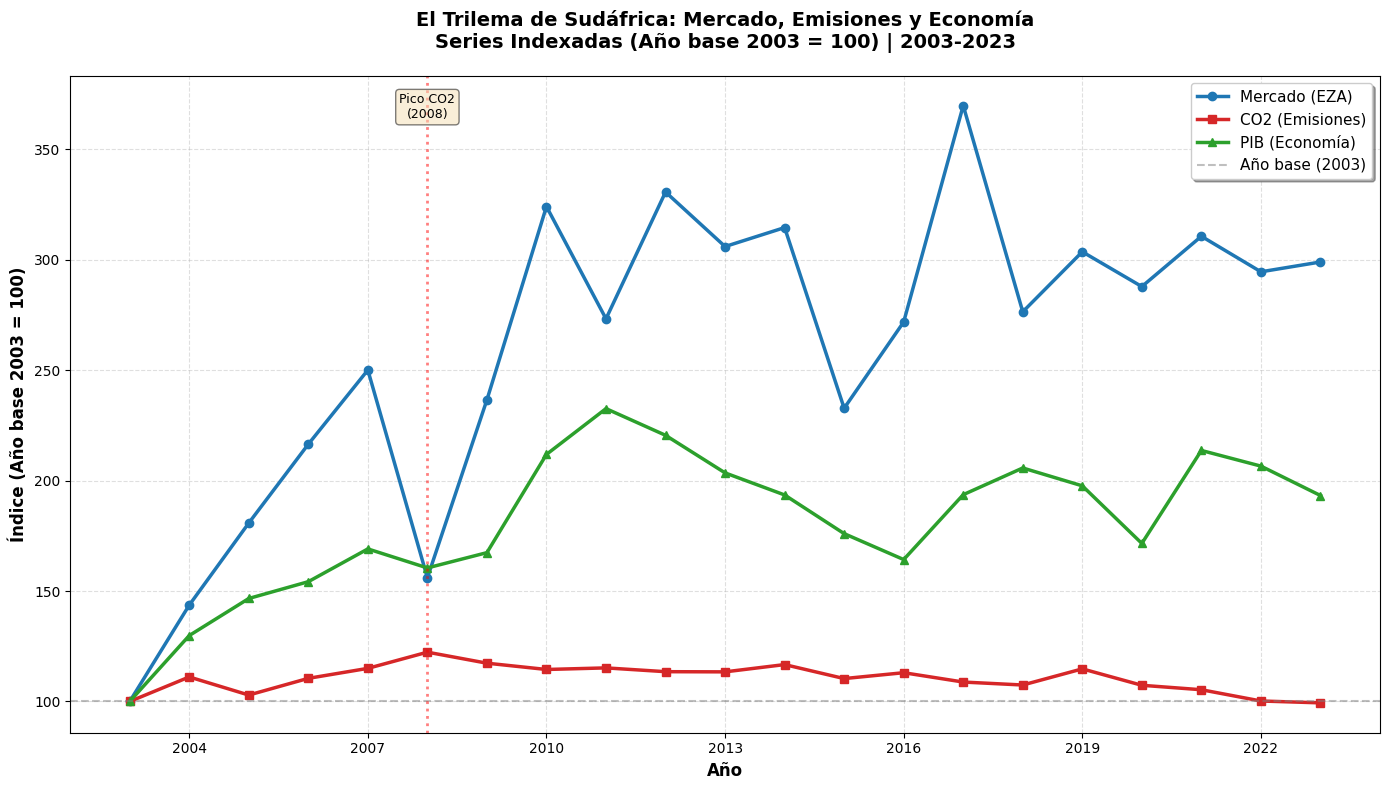

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import yfinance as yf
from pandas_datareader import wb
import warnings
warnings.filterwarnings('ignore')

# ========================================================================
# CONFIGURACIÓN: Cambia estos valores para analizar diferentes países
# ========================================================================

COUNTRIES = {
    'MEX': {'ticker': 'NAFTRACISHRS.MX', 'name': 'México', 'iso_csv': 'MEX', 'wb_code': 'MEX'},
    'AUS': {'ticker': 'EWA', 'name': 'Australia', 'iso_csv': 'AUS', 'wb_code': 'AUS'},
    'BRA': {'ticker': 'EWZ', 'name': 'Brasil', 'iso_csv': 'BRA', 'wb_code': 'BRA'},
    'CHN': {'ticker': 'FXI', 'name': 'China', 'iso_csv': 'CHN', 'wb_code': 'CHN'},
    'USA': {'ticker': 'VTI', 'name': 'Estados Unidos', 'iso_csv': 'USA', 'wb_code': 'USA'},
    'JPN': {'ticker': 'EWJ', 'name': 'Japón', 'iso_csv': 'JPN', 'wb_code': 'JPN'},
    'GBR': {'ticker': 'EWU', 'name': 'Reino Unido', 'iso_csv': 'GBR', 'wb_code': 'GBR'},
    'RUS': {'ticker': 'ERUS', 'name': 'Rusia', 'iso_csv': 'RUS', 'wb_code': 'RUS', 'end_year': 2021},
    'ESP': {'ticker': 'EWP', 'name': 'España', 'iso_csv': 'ESP', 'wb_code': 'ESP'},
    'ZAF': {'ticker': 'EZA', 'name': 'Sudáfrica', 'iso_csv': 'ZAF', 'wb_code': 'ZAF'},
}

# SELECCIONA EL PAÍS A ANALIZAR AQUÍ:
COUNTRY = 'ZAF'  # Cambia esto a: AUS, BRA, CHN, USA, JPN, GBR, RUS, ESP, ZAF

# ========================================================================

CSV_FILE_PATH = "emision-anual-co2-por-pais.csv"
START_YEAR = 2003
DEFAULT_END_YEAR = 2023

# Obtener configuración del país
country_config = COUNTRIES[COUNTRY]
TICKER = country_config['ticker']
COUNTRY_NAME = country_config['name']
ISO_CODE = country_config['iso_csv']
WB_CODE = country_config['wb_code']
END_YEAR = country_config.get('end_year', DEFAULT_END_YEAR)

# === Función para indexar (base 100) ===
def index_to_base_100(series):
    """Indexa una serie a base 100 (primer valor = 100)"""
    if len(series) == 0 or series.iloc[0] == 0:
        return pd.Series([100] * len(series), index=series.index)
    return (series / series.iloc[0]) * 100

print("="*80)
print(f"TRILEMA: {COUNTRY_NAME.upper()} - Mercado, Emisiones y Economía")
print("="*80)
print(f"País: {COUNTRY_NAME} ({COUNTRY})")
print(f"ETF/Índice: {TICKER}")
print(f"Período: {START_YEAR}-{END_YEAR}")
print(f"Método: INDEXACIÓN (Año base {START_YEAR} = 100)")
print("="*80)

# === 1. MERCADO (ETF/Índice) ===
print(f"\n[1/3] Descargando {TICKER}...")
try:
    data_market = yf.download(TICKER, start=f"{START_YEAR}-01-01", end=f"{END_YEAR}-12-31",
                              interval="1d", progress=False)

    if data_market.empty:
        raise Exception(f"No hay datos disponibles para {TICKER}")

    # Manejar MultiIndex si existe
    if isinstance(data_market.columns, pd.MultiIndex):
        data_market.columns = data_market.columns.droplevel(1)

    market_annual = data_market['Close'].resample('Y').last()
    df_market = pd.DataFrame({
        'Año': market_annual.index.year,
        'Mercado': market_annual.values.flatten()
    })
    print(f"✓ Obtenidos {len(df_market)} años ({df_market['Año'].min()}-{df_market['Año'].max()})")
except Exception as e:
    print(f"✗ ERROR: {e}")
    df_market = pd.DataFrame()

# === 2. EMISIONES CO2 ===
print(f"\n[2/3] Cargando emisiones CO2 para {ISO_CODE}...")
try:
    df_all = pd.read_csv(CSV_FILE_PATH)
    df_co2 = df_all[df_all['iso_pais'] == ISO_CODE].copy()

    if df_co2.empty:
        raise Exception(f"No se encontraron datos de CO2 para {ISO_CODE}")

    df_co2 = df_co2[df_co2['year'] >= START_YEAR]
    df_co2 = df_co2[df_co2['year'] <= END_YEAR]
    df_co2['CO2_Mt'] = df_co2['emision_co2_toneladas'] / 1_000_000
    df_co2 = df_co2[['year', 'CO2_Mt']].rename(columns={'year': 'Año'})
    print(f"✓ Obtenidos {len(df_co2)} años ({df_co2['Año'].min()}-{df_co2['Año'].max()})")
except Exception as e:
    print(f"✗ ERROR: {e}")
    df_co2 = pd.DataFrame()

# === 3. PIB ===
print(f"\n[3/3] Descargando PIB del Banco Mundial para {WB_CODE}...")
try:
    GDP_INDICATOR = 'NY.GDP.MKTP.CD'
    df_gdp_raw = wb.download(indicator=GDP_INDICATOR, country=WB_CODE,
                             start=START_YEAR, end=END_YEAR)

    if df_gdp_raw.empty:
        raise Exception(f"No hay datos de PIB para {WB_CODE}")

    df_gdp = df_gdp_raw.reset_index()
    df_gdp.rename(columns={'year': 'Año', GDP_INDICATOR: 'PIB'}, inplace=True)
    df_gdp['Año'] = pd.to_numeric(df_gdp['Año'])
    df_gdp = df_gdp.dropna(subset=['PIB']).sort_values(by='Año')
    print(f"✓ Obtenidos {len(df_gdp)} años ({df_gdp['Año'].min()}-{df_gdp['Año'].max()})")
except Exception as e:
    print(f"✗ ERROR: {e}")
    df_gdp = pd.DataFrame()

# === 4. VERIFICAR DATOS ===
if df_market.empty or df_co2.empty or df_gdp.empty:
    print("\n" + "="*80)
    print("ERROR: No se pudieron obtener todos los datos necesarios")
    print("="*80)
    if df_market.empty:
        print(f"- Mercado ({TICKER}): Sin datos")
    if df_co2.empty:
        print(f"- CO2 ({ISO_CODE}): Sin datos")
    if df_gdp.empty:
        print(f"- PIB ({WB_CODE}): Sin datos")
else:
    # === 5. UNIFICAR ===
    print(f"\n{'='*80}")
    print("UNIFICANDO DATOS...")
    df_merged = df_market.merge(df_co2, on='Año', how='inner').merge(df_gdp[['Año', 'PIB']], on='Año', how='inner')
    df_merged = df_merged.sort_values('Año').reset_index(drop=True)

    if df_merged.empty:
        print("✗ No hay años con datos completos para las 3 variables")
    else:
        print(f"✓ {len(df_merged)} años con datos completos ({int(df_merged['Año'].min())}-{int(df_merged['Año'].max())})")

        # === 6. INDEXAR A BASE 100 (Primer año = 100) ===
        año_base = int(df_merged['Año'].iloc[0])
        df_merged['Mercado_Index'] = index_to_base_100(df_merged['Mercado'])
        df_merged['CO2_Index'] = index_to_base_100(df_merged['CO2_Mt'])
        df_merged['PIB_Index'] = index_to_base_100(df_merged['PIB'])

        # === 7. ESTADÍSTICAS CLAVE ===
        print(f"\n{'='*80}")
        print("ESTADÍSTICAS CLAVE")
        print("="*80)

        año_inicio = int(df_merged['Año'].min())
        año_fin = int(df_merged['Año'].max())

        # Crecimiento total desde año base
        mercado_crecimiento = df_merged['Mercado_Index'].iloc[-1] - 100
        co2_crecimiento = df_merged['CO2_Index'].iloc[-1] - 100
        pib_crecimiento = df_merged['PIB_Index'].iloc[-1] - 100

        print(f"Año base: {año_base} (todos los índices = 100)")
        print(f"Año final: {año_fin}")
        print(f"\nCrecimiento total desde año base:")
        print(f"  • Mercado ({TICKER}):  {mercado_crecimiento:+.1f}% (índice: {df_merged['Mercado_Index'].iloc[-1]:.1f})")
        print(f"  • Emisiones CO2:       {co2_crecimiento:+.1f}% (índice: {df_merged['CO2_Index'].iloc[-1]:.1f})")
        print(f"  • PIB:                 {pib_crecimiento:+.1f}% (índice: {df_merged['PIB_Index'].iloc[-1]:.1f})")

        # Encontrar pico de CO2
        max_co2_idx = df_merged['CO2_Mt'].idxmax()
        año_pico_co2 = int(df_merged.loc[max_co2_idx, 'Año'])
        co2_pico = df_merged.loc[max_co2_idx, 'CO2_Mt']
        co2_pico_index = df_merged.loc[max_co2_idx, 'CO2_Index']
        co2_actual = df_merged['CO2_Mt'].iloc[-1]
        co2_actual_index = df_merged['CO2_Index'].iloc[-1]

        print(f"\nPico de emisiones CO2:")
        print(f"  • Año: {año_pico_co2}")
        print(f"  • Valor: {co2_pico:.2f} Mt (índice: {co2_pico_index:.1f})")
        if año_pico_co2 < año_fin:
            cambio_desde_pico = ((co2_actual / co2_pico) - 1) * 100
            print(f"  • Cambio desde pico hasta {año_fin}: {cambio_desde_pico:+.1f}%")
            print(f"    └─ De índice {co2_pico_index:.1f} a {co2_actual_index:.1f}")

        # Intensidad de carbono (CO2 por unidad de PIB)
        co2_intensity_inicio = df_merged['CO2_Mt'].iloc[0] / (df_merged['PIB'].iloc[0] / 1e12)
        co2_intensity_fin = df_merged['CO2_Mt'].iloc[-1] / (df_merged['PIB'].iloc[-1] / 1e12)
        mejora_intensidad = ((co2_intensity_fin / co2_intensity_inicio) - 1) * 100

        print(f"\nIntensidad de carbono (Mt CO2 por Trillón USD):")
        print(f"  • {año_inicio}: {co2_intensity_inicio:.1f} Mt/$T")
        print(f"  • {año_fin}: {co2_intensity_fin:.1f} Mt/$T")
        print(f"  • Cambio: {mejora_intensidad:+.1f}% {'(MEJORA)' if mejora_intensidad < 0 else '(EMPEORA)'}")

        # Desacoplamiento
        if pib_crecimiento > 0 and co2_crecimiento < 0:
            print(f"\n🌱 DESACOPLAMIENTO ABSOLUTO DETECTADO:")
            print(f"   PIB creció {pib_crecimiento:+.1f}% mientras CO2 bajó {co2_crecimiento:.1f}%")
        elif pib_crecimiento > co2_crecimiento and co2_crecimiento >= 0:
            elasticidad = co2_crecimiento / pib_crecimiento if pib_crecimiento != 0 else 0
            print(f"\n📉 Desacoplamiento relativo:")
            print(f"   Elasticidad CO2-PIB: {elasticidad:.2f}")
            print(f"   (Por cada 1% de crecimiento del PIB, CO2 crece {elasticidad:.2f}%)")

        # Correlaciones
        print(f"\nCorrelaciones (índices):")
        corr_mercado_co2 = df_merged['Mercado_Index'].corr(df_merged['CO2_Index'])
        corr_mercado_pib = df_merged['Mercado_Index'].corr(df_merged['PIB_Index'])
        corr_pib_co2 = df_merged['PIB_Index'].corr(df_merged['CO2_Index'])
        print(f"  • Mercado-CO2:  {corr_mercado_co2:.3f}")
        print(f"  • Mercado-PIB:  {corr_mercado_pib:.3f}")
        print(f"  • PIB-CO2:      {corr_pib_co2:.3f}")

        # Interpretación de correlaciones
        if corr_mercado_pib > corr_mercado_co2:
            print(f"\n💡 Interpretación: El mercado sigue MÁS al PIB que al CO2")
            print(f"   (Economía de servicios/financiera más que industrial)")
        else:
            print(f"\n💡 Interpretación: El mercado sigue MÁS al CO2 que al PIB")
            print(f"   (Economía industrial/extractiva)")

        # === 8. MOSTRAR TABLA ===
        print(f"\n{'='*80}")
        print("TABLA UNIFICADA (Indexada, año base = 100)")
        print("="*80)
        display_df = df_merged[['Año', 'Mercado', 'CO2_Mt', 'PIB', 'Mercado_Index', 'CO2_Index', 'PIB_Index']].copy()
        display_df['PIB'] = display_df['PIB'].apply(lambda x: f"{x/1e12:.2f}T")
        print(display_df.to_string(index=False, float_format=lambda x: f"{x:.2f}"))

        # === 9. GRÁFICA DE SERIES INDEXADAS ===
        print(f"\n{'='*80}")
        print("GENERANDO GRÁFICA...")
        print("="*80)

        fig, ax = plt.subplots(figsize=(14, 8))

        # Las 3 líneas indexadas
        ax.plot(df_merged['Año'], df_merged['Mercado_Index'],
                marker='o', linewidth=2.5, markersize=6, label=f'Mercado ({TICKER})', color='#1f77b4')
        ax.plot(df_merged['Año'], df_merged['CO2_Index'],
                marker='s', linewidth=2.5, markersize=6, label='CO2 (Emisiones)', color='#d62728')
        ax.plot(df_merged['Año'], df_merged['PIB_Index'],
                marker='^', linewidth=2.5, markersize=6, label='PIB (Economía)', color='#2ca02c')

        # Línea base de referencia
        ax.axhline(y=100, color='gray', linestyle='--', linewidth=1.5, alpha=0.5, label=f'Año base ({año_base})')

        # Marcar pico de CO2
        ax.axvline(x=año_pico_co2, color='red', linestyle=':', linewidth=2, alpha=0.5)
        ax.text(año_pico_co2, ax.get_ylim()[1] * 0.95, f'Pico CO2\n({año_pico_co2})',
                ha='center', fontsize=9, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

        ax.set_title(f'El Trilema de {COUNTRY_NAME}: Mercado, Emisiones y Economía\n' +
                     f'Series Indexadas (Año base {año_base} = 100) | {año_inicio}-{año_fin}',
                     fontsize=14, fontweight='bold', pad=20)
        ax.set_xlabel('Año', fontsize=12, fontweight='bold')
        ax.set_ylabel(f'Índice (Año base {año_base} = 100)', fontsize=12, fontweight='bold')

        ax.legend(loc='best', fontsize=11, frameon=True, shadow=True, fancybox=True)
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

        # Formato del eje Y
        ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:.0f}'))

        plt.tight_layout()
        plt.show()